In [4]:
import os # For finding files
import numpy as np # For math and IQR calculations
import matplotlib.pyplot as plt # For standard plotting
import seaborn as sns # For drawing the boxplot
import matplotlib.image as mpimg # To open images

In [5]:
base_dir = r'C:\Users\vinuga janandith\Desktop\AIML project\data'

brightness_values = []
image_paths = [] 

print("Calculating average brightness for ALL images...")
# Loop through all folders to read images
for root, dirs, files in os.walk(base_dir):
    if not dirs: 
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    img = mpimg.imread(file_path)
                    if img is not None:
                        # Calculate the average pixel brightness of the image
                        mean_brightness = np.mean(img)
                        brightness_values.append(mean_brightness)
                        image_paths.append(file_path) 
                except Exception:
                    pass 

# DATA PREPROCESSING: Outlier Detection (IQR Method)

# Calculate Q1, Q3, and the Interquartile Range (IQR)
Q1 = np.percentile(brightness_values, 25)
Q3 = np.percentile(brightness_values, 75)
IQR = Q3 - Q1

# Set the lower and upper boundaries for normal images
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find exactly which images fall outside the normal boundaries
outliers = [path for path, b in zip(image_paths, brightness_values) if b < lower_bound or b > upper_bound]

# Print the outlier results
print("-" * 40)
print(f"Total images analyzed: {len(brightness_values)}")
print(f"Normal Brightness Range: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Number of Outlier Images detected: {len(outliers)}")
print("-" * 40)

Calculating average brightness for ALL images...
----------------------------------------
Total images analyzed: 9660
Normal Brightness Range: 2.56 to 235.13
Number of Outlier Images detected: 31
----------------------------------------


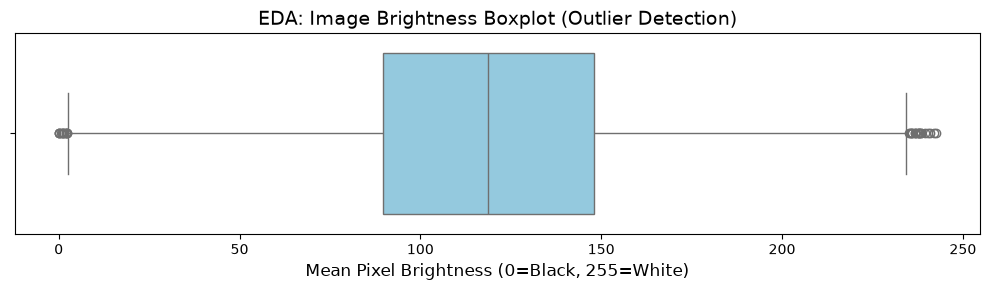

In [3]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Draw a Boxplot to visually identify outliers
plt.figure(figsize=(10, 3))
sns.boxplot(x=brightness_values, color='skyblue')

plt.title('EDA: Image Brightness Boxplot (Outlier Detection)', fontsize=14)
plt.xlabel('Mean Pixel Brightness (0=Black, 255=White)', fontsize=12)

plt.tight_layout()
plt.show()